In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import f1_score, classification_report

In [3]:
train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample_sub = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [5]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB


In [6]:
train_df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [7]:
train_df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [8]:
test_df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2
count,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000
mean,68.359422,0.280078,0.048353,0.118902,2.609402,0.661667,1.903078,7.956206
std,27.923491,1.043353,0.257278,0.480484,4.966033,1.965536,26.273483,15.186746
min,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000
max,129.000000,95.000000,8.000000,19.000000,189.000000,95.000000,1866.000000,1798.000000


In [9]:
nc = train_df.select_dtypes("number").columns
print(nc)
cc = train_df.select_dtypes("object").columns
print(cc)

Index(['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote',
       'downvote', 'if_1', 'if_2', 'label'],
      dtype='object')
Index(['created_date', 'race', 'religion', 'gender', 'comment'], dtype='object')


In [10]:
#Label Distribution
train_df["label"].value_counts()

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

In [11]:
#Label proprortions
train_df["label"].value_counts(normalize=True)
#Insight 1: Dataset is imbalanced 
#Label 0 dominates with 57.6% , Label 3 is rare at 2.7%

label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64

In [12]:
train_df.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [13]:
test_df.isnull().sum()

created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64

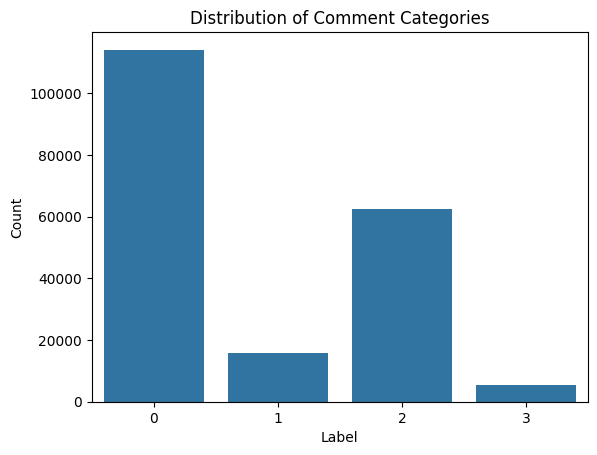

In [14]:
sns.countplot(x=train_df["label"])
plt.title("Distribution of Comment Categories")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()
#This plot shows how many samples belong to each category.
#This visualization helps understand the distribution of target classes and reveals whether the dataset is imbalanced.

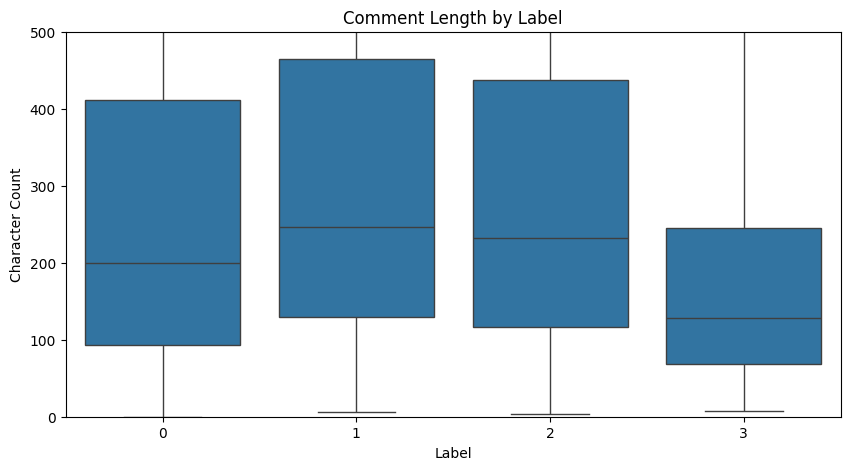

In [15]:
train_df["comment_length"] = train_df["comment"].fillna("").str.len()

plt.figure(figsize=(10, 5))
sns.boxplot(x="label", y="comment_length", data=train_df)
plt.title("Comment Length by Label")
plt.xlabel("Label")
plt.ylabel("Character Count")
plt.ylim(0, 500)
plt.show()

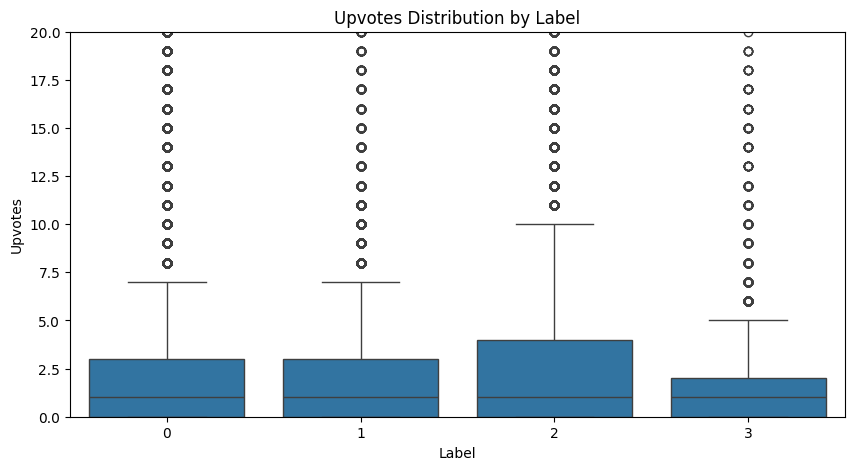

In [16]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="label", y="upvote", data=train_df)
plt.title("Upvotes Distribution by Label")
plt.xlabel("Label")
plt.ylabel("Upvotes")
plt.ylim(0, 20)
plt.show()

In [17]:
train_df["comment"] = train_df["comment"].fillna("")
test_df["comment"] = test_df["comment"].fillna("")

for col in ["race","religion","gender"]:
    train_df[col] = train_df[col].fillna("none")
    test_df[col] = test_df[col].fillna("none")

In [18]:
train_df.isnull().sum()

created_date      0
post_id           0
emoticon_1        0
emoticon_2        0
emoticon_3        0
upvote            0
downvote          0
if_1              0
if_2              0
race              0
religion          0
gender            0
disability        0
comment           0
label             0
comment_length    0
dtype: int64

In [19]:
test_df.isnull().sum()

created_date    0
post_id         0
emoticon_1      0
emoticon_2      0
emoticon_3      0
upvote          0
downvote        0
if_1            0
if_2            0
race            0
religion        0
gender          0
disability      0
comment         0
dtype: int64

In [20]:
#Feature Engineering - DateTime features
'''train_df["created_date"] = pd.to_datetime(train_df["created_date"], utc=True)
test_df["created_date"] = pd.to_datetime(test_df["created_date"], utc=True)
train_df["month"] = train_df["created_date"].dt.month_name().str.lower()

for df in [train_df, test_df]:
    df["month"]     = df["created_date"].dt.month
    df["hour"]      = df["created_date"].dt.hour
    df["dayofweek"] = df["created_date"].dt.dayofweek
    df["year"]      = df["created_date"].dt.year

#Total emoticons
train_df["total_emoticons"] = train_df["emoticon_1"] + train_df["emoticon_2"] + train_df["emoticon_3"]
test_df["total_emoticons"]  = test_df["emoticon_1"]  + test_df["emoticon_2"]  + test_df["emoticon_3"]
'''
    

'train_df["created_date"] = pd.to_datetime(train_df["created_date"], utc=True)\ntest_df["created_date"] = pd.to_datetime(test_df["created_date"], utc=True)\ntrain_df["month"] = train_df["created_date"].dt.month_name().str.lower()\n\nfor df in [train_df, test_df]:\n    df["month"]     = df["created_date"].dt.month\n    df["hour"]      = df["created_date"].dt.hour\n    df["dayofweek"] = df["created_date"].dt.dayofweek\n    df["year"]      = df["created_date"].dt.year\n\n#Total emoticons\ntrain_df["total_emoticons"] = train_df["emoticon_1"] + train_df["emoticon_2"] + train_df["emoticon_3"]\ntest_df["total_emoticons"]  = test_df["emoticon_1"]  + test_df["emoticon_2"]  + test_df["emoticon_3"]\n'

In [21]:
text_col = "comment"
categorical_cols = ["race","religion","gender"]
numerical_cols = [ "emoticon_1", "emoticon_2", "emoticon_3",
    "upvote", "downvote", "if_1", "if_2", "disability"
    ]

In [22]:
y = train_df["label"]
X = train_df.drop(columns=["label"])

In [23]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [24]:
print("Train size:",X_tr.shape)
print("Test size:",X_val.shape)

Train size: (158400, 15)
Test size: (39600, 15)


In [25]:
#Preprocessor (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ("text",
         TfidfVectorizer(
             max_features=40000,
             ngram_range=(1,2),
             stop_words="english",
             min_df=2,
             max_df=0.9,
             sublinear_tf=True
         ),
         text_col),

        ("cat",
         OneHotEncoder(handle_unknown="ignore"),
         categorical_cols),

        ("num",
         "passthrough",
         numerical_cols)
    ]
)

In [26]:
X_tr_proc = preprocessor.fit_transform(X_tr)
X_val_proc = preprocessor.transform(X_val)

In [27]:
print(X_tr_proc.shape)

(158400, 40027)


In [28]:
#--Logistic Regression--
log_model = LogisticRegression(
    solver="lbfgs",
    max_iter=2000,
    class_weight="balanced",
    C=2
)

log_model.fit(X_tr_proc, y_tr)
pred_log = log_model.predict(X_val_proc)
print("Logistic Regression F1:",
      f1_score(y_val, pred_log, average="macro"))

#F1: 0.7694351299023474

Logistic Regression F1: 0.786192792403126


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
#--Linear SVM--
svm_model = LinearSVC(
    C=1.5,
    class_weight="balanced"
)

svm_model.fit(X_tr_proc, y_tr)
pred_svm = svm_model.predict(X_val_proc)
print("Linear SVM F1:",
      f1_score(y_val, pred_svm, average="macro"))
#F1 : 0.6798039021809286

Linear SVM F1: 0.6798039021809386


In [30]:
#--SGD Classifier--
sgd_model = SGDClassifier(
    loss="hinge",
    alpha=1e-4,
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

sgd_model.fit(X_tr_proc, y_tr)
pred_sgd = sgd_model.predict(X_val_proc)
print("SGD Classifier F1:",
      f1_score(y_val, pred_sgd, average="macro"))
#F1: 0.6248081367897058

SGD Classifier F1: 0.6248081367897058


In [31]:
#--Random Forest Classifier--
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_tr_proc, y_tr)

pred_rf = rf_model.predict(X_val_proc)

print("Random Forest F1:",
      f1_score(y_val, pred_rf, average="macro"))

#F1:0.6497984671425495

Random Forest F1: 0.6497984671425495


In [32]:
#Before tuning with 30000 tfidf
'''lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_tr, y_tr)

pred_lgb = lgb_model.predict(X_val)

print("LightGBM F1:",
      f1_score(y_val, pred_lgb, average="macro"))'''

'lgb_model = LGBMClassifier(\n    n_estimators=500,\n    learning_rate=0.05,\n    num_leaves=31,\n    class_weight="balanced",\n    random_state=42,\n    verbose=-1\n)\n\nlgb_model.fit(X_tr, y_tr)\n\npred_lgb = lgb_model.predict(X_val)\n\nprint("LightGBM F1:",\n      f1_score(y_val, pred_lgb, average="macro"))'

In [33]:
lgb_model = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=50,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

lgb_model.fit(X_tr_proc, y_tr)   
pred_lgb = lgb_model.predict(X_val_proc)
print("LightGBM F1:",
      f1_score(y_val, pred_lgb, average="macro"))

#F1: 0.8031154110685529

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM F1: 0.8031154110685529


In [34]:
#Model Comparison Summary
print("Model Comparison")

print("Logistic Regression:",
      f1_score(y_val, pred_log, average="macro"))

print("Linear SVM:",
      f1_score(y_val, pred_svm, average="macro"))

print("SGD Classifier:",
      f1_score(y_val, pred_sgd, average="macro"))

print("Random Forest:",
      f1_score(y_val, pred_rf, average="macro"))

print("LightGBM:",
      f1_score(y_val, pred_lgb, average="macro"))

Model Comparison
Logistic Regression: 0.786192792403126
Linear SVM: 0.6798039021809386
SGD Classifier: 0.6248081367897058
Random Forest: 0.6497984671425495
LightGBM: 0.8031154110685529


In [35]:
# Detailed classification report for best model
print("\nDetailed Report — LightGBM (Best Model):")
print(classification_report(y_val, pred_lgb,
      target_names=["Class 0","Class 1","Class 2","Class 3"]))


Detailed Report — LightGBM (Best Model):
              precision    recall  f1-score   support

     Class 0       0.98      0.94      0.96     22835
     Class 1       0.70      0.86      0.77      3183
     Class 2       0.89      0.86      0.88     12488
     Class 3       0.50      0.76      0.60      1094

    accuracy                           0.91     39600
   macro avg       0.77      0.86      0.80     39600
weighted avg       0.92      0.91      0.91     39600



In [36]:
'''#Pipeline combines preprocessor and the best model in one object
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        class_weight="balanced",
        random_state=42,
        verbose=-1,
        n_jobs=-1
    ))
])

# Train pipeline on training data
pipeline.fit(X_tr, y_tr)

# Predict using pipeline (handles preprocessing automatically!)
pred_pipeline = pipeline.predict(X_val)
print("Pipeline LightGBM F1:",
      f1_score(y_val, pred_pipeline, average="macro"))'''

'#Pipeline combines preprocessor and the best model in one object\npipeline = Pipeline([\n    ("preprocessor", preprocessor),\n    ("classifier", LGBMClassifier(\n        class_weight="balanced",\n        random_state=42,\n        verbose=-1,\n        n_jobs=-1\n    ))\n])\n\n# Train pipeline on training data\npipeline.fit(X_tr, y_tr)\n\n# Predict using pipeline (handles preprocessing automatically!)\npred_pipeline = pipeline.predict(X_val)\nprint("Pipeline LightGBM F1:",\n      f1_score(y_val, pred_pipeline, average="macro"))'

In [37]:
'''param_dist = {
    "n_estimators":     [600, 800, 1000],
    "learning_rate":    [0.02, 0.03, 0.05],
    "num_leaves":       [40, 50, 70],
    "min_child_samples":[20, 30],
    "reg_alpha":        [0, 0.01, 0.1],
}

search = RandomizedSearchCV(
    LGBMClassifier(class_weight="balanced", random_state=42, verbose=-1),
    param_distributions=param_dist,
    n_iter=15,      # only 45 fits total
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)
search.fit(X_full_proc, y)
print("Best params:", search.best_params_)
print("Best CV F1:", search.best_score_)'''

'param_dist = {\n    "n_estimators":     [600, 800, 1000],\n    "learning_rate":    [0.02, 0.03, 0.05],\n    "num_leaves":       [40, 50, 70],\n    "min_child_samples":[20, 30],\n    "reg_alpha":        [0, 0.01, 0.1],\n}\n\nsearch = RandomizedSearchCV(\n    LGBMClassifier(class_weight="balanced", random_state=42, verbose=-1),\n    param_distributions=param_dist,\n    n_iter=15,      # only 45 fits total\n    scoring="f1_macro",\n    cv=3,\n    n_jobs=-1,\n    random_state=42,\n    verbose=2\n)\nsearch.fit(X_full_proc, y)\nprint("Best params:", search.best_params_)\nprint("Best CV F1:", search.best_score_)'

In [38]:
#Transformin the full data for training
X_full_proc = preprocessor.fit_transform(X)

In [39]:
final_model = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=50,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

In [40]:
final_model.fit(X_full_proc, y)

LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.03, n_estimators=800, n_jobs=-1, num_leaves=50,
               random_state=42, subsample=0.8, verbose=-1)

In [41]:
X_test_proc = preprocessor.transform(test_df)
final_pred = final_model.predict(X_test_proc)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [42]:
submission = sample_sub.copy()
submission["label"] = final_pred

submission.to_csv("submission.csv", index=False)
print("\nsubmission.csv saved ")


submission.csv saved 
